# DATA 266 HW1 Neural Networks

In [ ]:
import os
import random
import numpy as np
import torch
import tensorflow as tf

SID4 = 9486
SEED = SID4
SLICE = SID4 % 1000
HP_ID = SID4 % 6
CLS_A = SID4 % 10
CLS_B = (CLS_A + 1 + ((SID4 // 10) % 9)) % 10

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
tf.random.set_seed(SEED)

print(f"SID4  = {SID4}")
print(f"SEED  = {SEED}")
print(f"SLICE = {SLICE}")
print(f"HP_ID = {HP_ID}")
print(f"CLS_A = {CLS_A}")
print(f"CLS_B = {CLS_B}")


SID4  = 9486
SEED  = 9486
SLICE = 486
HP_ID = 0
CLS_A = 6
CLS_B = 0


In [ ]:
BASELINE_CONFIG = {
    "hidden_layers": [64, 32],
    "learning_rate": 0.001,
    "epochs": 30
}

MODIFIED_CONFIG = {
    "hidden_layers": [32],
    "learning_rate": 0.001,
    "epochs": 30
}

TRAINING_SEEDS = [SEED, SEED + 1, SEED + 2]

print("Baseline configuration:", BASELINE_CONFIG)
print("Modified configuration:", MODIFIED_CONFIG)
print("Training seeds:", TRAINING_SEEDS)


Baseline configuration: {'hidden_layers': [64, 32], 'learning_rate': 0.001, 'epochs': 30}
Modified configuration: {'hidden_layers': [32], 'learning_rate': 0.001, 'epochs': 30}
Training seeds: [9486, 9487, 9488]


## 2. Diabetes Dataset

This section loads and inspects the diabetes dataset before preprocessing. No values are modified during this initial inspection.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

DATA_PATH = Path("data/diabetes.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH}")

# The supplied CSV is headerless, so preserve its first row as data.
df = pd.read_csv(DATA_PATH, header=None)
RAW_SHAPE = df.shape
COLUMN_NAMES = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "SourceLabel",
]
df.columns = COLUMN_NAMES

print("Dataset path:", DATA_PATH)
print("Dataset shape:", RAW_SHAPE)
print("Column names:", list(df.columns))
display(df.head())

Dataset path: data/diabetes.csv
Dataset shape: (759, 9)
Column names: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'SourceLabel']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,SourceLabel
0,-0.294118,0.487437,0.180328,-0.292929,0.000000,0.001490,-0.531170,-0.033333,0
1,-0.882353,-0.145729,0.081967,-0.414141,0.000000,-0.207153,-0.766866,-0.666667,1
2,-0.058824,0.839196,0.049180,0.000000,0.000000,-0.305514,-0.492741,-0.633333,0
3,-0.882353,-0.105528,0.081967,-0.535354,-0.777778,-0.162444,-0.923997,0.000000,1
4,0.000000,0.376884,-0.344262,-0.292929,-0.602837,0.284650,0.887276,-0.600000,0


In [ ]:
print("DataFrame information:")
df.info()

print("Descriptive statistics:")
display(df.describe().T)

DataFrame information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 759 entries, 0 to 758
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               759 non-null    float64
 1   Glucose                   759 non-null    float64
 2   BloodPressure             759 non-null    float64
 3   SkinThickness             759 non-null    float64
 4   Insulin                   759 non-null    float64
 5   BMI                       759 non-null    float64
 6   DiabetesPedigreeFunction  759 non-null    float64
 7   Age                       759 non-null    float64
 8   SourceLabel               759 non-null    int64  
dtypes: float64(8), int64(1)
memory usage: 53.5 KB
Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
Pregnancies,759.0,-0.407657,0.386260,-0.882353,-0.764706,-0.529412,0.000000,1.0
Glucose,759.0,0.218563,0.306419,-0.557789,-0.005025,0.165829,0.407035,1.0
BloodPressure,759.0,0.176505,0.201287,-0.606557,0.016393,0.180328,0.311475,1.0
SkinThickness,759.0,-0.289735,0.258480,-0.858586,-0.494949,-0.292929,0.000000,1.0
Insulin,759.0,-0.323534,0.375544,-0.966903,-0.716312,0.000000,0.000000,1.0
BMI,759.0,-0.032245,0.205376,-0.457526,-0.178837,-0.034277,0.087929,1.0
DiabetesPedigreeFunction,759.0,-0.663253,0.283056,-0.994876,-0.858241,-0.747225,-0.531597,1.0
Age,759.0,-0.516162,0.400794,-0.966667,-0.866667,-0.633333,-0.233333,1.0
SourceLabel,759.0,0.653491,0.476171,0.000000,0.000000,1.000000,1.000000,1.0


In [ ]:
print("Missing-value counts:")
display(df.isna().sum().rename("missing_values"))

print("Duplicate-row count:", int(df.duplicated().sum()))

print("Zero-value counts for numeric columns:")
display((df.select_dtypes(include="number") == 0).sum().rename("zero_values"))

Missing-value counts:


,missing_values
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
SourceLabel,0


Duplicate-row count: 0
Zero-value counts for numeric columns:


,zero_values
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,224
Insulin,371
BMI,11
DiabetesPedigreeFunction,1
Age,63
SourceLabel,263


In [ ]:
# The headerless dataset uses its final column as the binary target.
TARGET_COLUMN = df.columns[-1]
target_values = sorted(df[TARGET_COLUMN].dropna().unique().tolist())
target_counts = df[TARGET_COLUMN].value_counts().sort_index()
target_percentages = (
    df[TARGET_COLUMN].value_counts(normalize=True).sort_index() * 100
).round(4)

print("Confirmed target column:", TARGET_COLUMN)
print("Target unique values:", target_values)
print("Target class counts:")
display(target_counts.rename("count"))
print("Target class percentages:")
display(target_percentages.rename("percentage"))

Confirmed target column: SourceLabel
Target unique values: [0, 1]
Target class counts:


,count
SourceLabel,
0,263
1,496


Target class percentages:


,percentage
SourceLabel,
0,34.6509
1,65.3491


### Initial Observations

- The dataset contains 759 rows and 9 source columns, giving 8 input features and 1 source-label column.
- The CSV is headerless, but its matched schema uses the standard order: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age, and SourceLabel.
- SourceLabel is binary with values `0` and `1`; the assignment-provided encoding is `0 = diabetes` and `1 = no diabetes`. The modeling target will be remapped later as `Diabetes = 1 - SourceLabel`, so `Diabetes=1` means diabetes.
- There are no explicit missing values and no duplicate rows. The source features are already scaled approximately to `[-1, 1]`.
- Zero is valid for Pregnancies, DiabetesPedigreeFunction, Age, and SourceLabel. Zero is a missing-value sentinel for Glucose (5), BloodPressure (35), SkinThickness (224), Insulin (371), and BMI (11).
- These sentinel zeros are retained during this inspection and will be handled during preprocessing rather than changed here.

## 3. Preprocessing and Fixed Data Split

### 3.1 Feature and Target Definitions

In [ ]:
# Confirm the semantic schema and create the modeling target.
COLUMN_NAMES = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "SourceLabel",
]
assert list(df.columns) == COLUMN_NAMES
assert RAW_SHAPE == (759, 9)
assert set(df["SourceLabel"].unique()) == {0, 1}

df["Diabetes"] = 1 - df["SourceLabel"]
assert set(df["Diabetes"].unique()) == {0, 1}
assert df["Diabetes"].value_counts().to_dict() == {0: 496, 1: 263}

FEATURE_NAMES = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
]
MISSING_ZERO_COLUMNS = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
]

X = df[FEATURE_NAMES].copy()
y = df["Diabetes"].astype("int64").copy()

print("SourceLabel distribution:")
display(df["SourceLabel"].value_counts().sort_index().rename("count"))
print("Remapped Diabetes distribution:")
display(y.value_counts().sort_index().rename("count"))

SourceLabel distribution:


,count
SourceLabel,
0,263
1,496


Remapped Diabetes distribution:


,count
Diabetes,
0,496
1,263


### 3.2 Missing-Value Treatment

In [ ]:
# Replace only medically invalid zero sentinels; preserve valid zeros.
X[MISSING_ZERO_COLUMNS] = X[MISSING_ZERO_COLUMNS].replace(0, np.nan)
missing_sentinel_counts = X.isna().sum()
expected_missing_sentinel_counts = pd.Series({
    "Glucose": 5,
    "BloodPressure": 35,
    "SkinThickness": 224,
    "Insulin": 371,
    "BMI": 11,
})
assert missing_sentinel_counts[MISSING_ZERO_COLUMNS].equals(expected_missing_sentinel_counts)
print("Missing-sentinel counts after replacement:")
display(missing_sentinel_counts)

Missing-sentinel counts after replacement:


,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,224
Insulin,371
BMI,11
DiabetesPedigreeFunction,0
Age,0


### 3.3 Fixed 70/15/15 Split

In [ ]:
from sklearn.model_selection import train_test_split

# Split row indices so both frameworks use the exact same observations.
ROW_INDICES = np.arange(len(df))
train_indices, temporary_indices = train_test_split(
    ROW_INDICES,
    test_size=0.30,
    random_state=SEED,
    stratify=y,
)
validation_indices, test_indices = train_test_split(
    temporary_indices,
    test_size=0.50,
    random_state=SEED,
    stratify=y.iloc[temporary_indices],
)

assert len(train_indices) == 531
assert len(validation_indices) == 114
assert len(test_indices) == 114
assert len(set(train_indices) & set(validation_indices)) == 0
assert len(set(train_indices) & set(test_indices)) == 0
assert len(set(validation_indices) & set(test_indices)) == 0
assert len(set(train_indices) | set(validation_indices) | set(test_indices)) == len(df)
assert set(train_indices) | set(validation_indices) | set(test_indices) == set(ROW_INDICES)

X_train_raw = X.iloc[train_indices].copy()
X_val_raw = X.iloc[validation_indices].copy()
X_test_raw = X.iloc[test_indices].copy()
y_train_int = y.iloc[train_indices].copy()
y_val_int = y.iloc[validation_indices].copy()
y_test_int = y.iloc[test_indices].copy()

print("Split sizes:", {
    "train": len(train_indices),
    "validation": len(validation_indices),
    "test": len(test_indices),
})
for split_name, split_target in {
    "train": y_train_int,
    "validation": y_val_int,
    "test": y_test_int,
}.items():
    distribution = pd.DataFrame({
        "count": split_target.value_counts().sort_index(),
        "percentage": (split_target.value_counts(normalize=True).sort_index() * 100).round(4),
    })
    print(f"{split_name} class distribution:")
    display(distribution)

Split sizes: {'train': 531, 'validation': 114, 'test': 114}
train class distribution:


,count,percentage
Diabetes,,
0,347,65.3484
1,184,34.6516


validation class distribution:


,count,percentage
Diabetes,,
0,75,65.7895
1,39,34.2105


test class distribution:


,count,percentage
Diabetes,,
0,74,64.9123
1,40,35.0877


### 3.4 Training-Only Imputation and Scaling

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Fit both preprocessing steps on training data only to prevent leakage.
imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train_raw)
X_val_imputed = imputer.transform(X_val_raw)
X_test_imputed = imputer.transform(X_test_raw)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_imputed).astype(np.float32)
X_val = scaler.transform(X_val_imputed).astype(np.float32)
X_test = scaler.transform(X_test_imputed).astype(np.float32)

y_train = y_train_int.to_numpy(dtype=np.float32)
y_val = y_val_int.to_numpy(dtype=np.float32)
y_test = y_test_int.to_numpy(dtype=np.float32)

assert not np.isnan(X_train).any()
assert not np.isnan(X_val).any()
assert not np.isnan(X_test).any()

print("Preprocessing complete: median imputation and StandardScaler were fit on X_train only.")

Preprocessing complete: median imputation and StandardScaler were fit on X_train only.


### 3.5 Preprocessing Verification

In [ ]:
def print_split_verification(name, features, target):
    counts = pd.Series(target).value_counts().sort_index()
    percentages = (pd.Series(target).value_counts(normalize=True).sort_index() * 100).round(4)
    print(f"{name} shape: X={features.shape}, y={target.shape}")
    print(f"{name} class counts: {counts.to_dict()}")
    print(f"{name} class percentages: {percentages.to_dict()}")

print("Raw dataset shape:", RAW_SHAPE)
print("Feature names:", FEATURE_NAMES)
print_split_verification("Train", X_train, y_train)
print_split_verification("Validation", X_val, y_val)
print_split_verification("Test", X_test, y_test)
print("NaN values remaining:", {
    "train": int(np.isnan(X_train).sum()),
    "validation": int(np.isnan(X_val).sum()),
    "test": int(np.isnan(X_test).sum()),
})
print("Final dtypes:", {
    "X_train": X_train.dtype,
    "X_val": X_val.dtype,
    "X_test": X_test.dtype,
    "y_train": y_train.dtype,
    "y_val": y_val.dtype,
    "y_test": y_test.dtype,
})
print("Training feature means:", np.round(X_train.mean(axis=0), 8))
print("Training feature standard deviations:", np.round(X_train.std(axis=0), 8))
print("Index overlap checks:", {
    "train_validation": len(set(train_indices) & set(validation_indices)) == 0,
    "train_test": len(set(train_indices) & set(test_indices)) == 0,
    "validation_test": len(set(validation_indices) & set(test_indices)) == 0,
    "complete_coverage": set(train_indices) | set(validation_indices) | set(test_indices) == set(ROW_INDICES),
})

Raw dataset shape: (759, 9)
Feature names: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Train shape: X=(531, 8), y=(531,)
Train class counts: {0.0: 347, 1.0: 184}
Train class percentages: {0.0: 65.3484, 1.0: 34.6516}
Validation shape: X=(114, 8), y=(114,)
Validation class counts: {0.0: 75, 1.0: 39}
Validation class percentages: {0.0: 65.7895, 1.0: 34.2105}
Test shape: X=(114, 8), y=(114,)
Test class counts: {0.0: 74, 1.0: 40}
Test class percentages: {0.0: 64.9123, 1.0: 35.0877}
NaN values remaining: {'train': 0, 'validation': 0, 'test': 0}
Final dtypes: {'X_train': dtype('float32'), 'X_val': dtype('float32'), 'X_test': dtype('float32'), 'y_train': dtype('float32'), 'y_val': dtype('float32'), 'y_test': dtype('float32')}
Training feature means: [-1.e-08  0.e+00 -0.e+00 -1.e-08  0.e+00 -0.e+00 -0.e+00  0.e+00]
Training feature standard deviations: [1. 1. 1. 1. 1. 1. 1. 1.]
Index overlap checks: {'train_validation': True,

The imputer and scaler are fit only on the training subset so that information from validation and test rows cannot influence the learned median or scaling parameters. This prevents data leakage and keeps the validation and test measurements honest for later model evaluation. The resulting processed arrays and saved row-index splits are shared by the PyTorch and TensorFlow experiments.

## 4. Exploratory Data Visualization

These figures use the full dataset for descriptive analysis. Medically invalid zero sentinels are treated as missing only in Glucose, BloodPressure, SkinThickness, Insulin, and BMI; valid zeros in the other columns are preserved.

### 4.1 Correlation Matrix

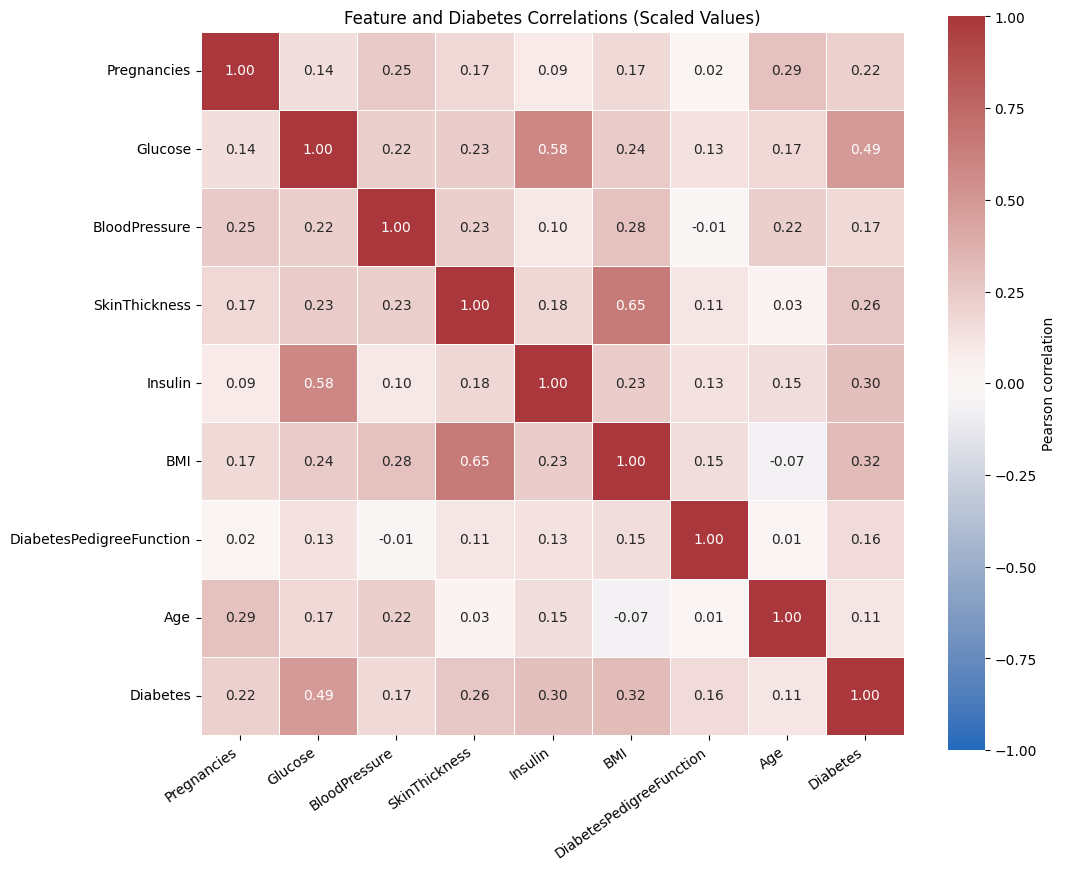

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

EDA_FEATURE_NAMES = FEATURE_NAMES.copy()
eda_df = df[EDA_FEATURE_NAMES].copy()
eda_df[MISSING_ZERO_COLUMNS] = eda_df[MISSING_ZERO_COLUMNS].replace(0, np.nan)
eda_df["Diabetes"] = df["Diabetes"]

correlation_matrix = eda_df.corr(method="pearson")
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(11, 9))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Pearson correlation"},
)
plt.title("Feature and Diabetes Correlations (Scaled Values)")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
feature_target_correlations = (
    correlation_matrix["Diabetes"]
    .drop("Diabetes")
    .sort_values(key=lambda values: values.abs(), ascending=False)
)
print("Feature-to-target correlations sorted by absolute magnitude:")
display(feature_target_correlations.rename("Pearson correlation"))

Feature-to-target correlations sorted by absolute magnitude:


,Pearson correlation
Glucose,0.491538
BMI,0.315051
Insulin,0.303797
SkinThickness,0.262079
Pregnancies,0.218405
BloodPressure,0.169221
DiabetesPedigreeFunction,0.163246
Age,0.112565


Glucose has the strongest positive relationship with the remapped Diabetes target (r = 0.491538), followed by BMI (r = 0.315051) and Insulin (r = 0.303797). Age has the weakest positive relationship (r = 0.112565), while no feature has a negative feature-to-target correlation in this descriptive analysis. Most relationships with the target are weak to moderate. These correlations describe linear association in the observed data and do not establish causation or medical effects.

### 4.2 Feature Distributions

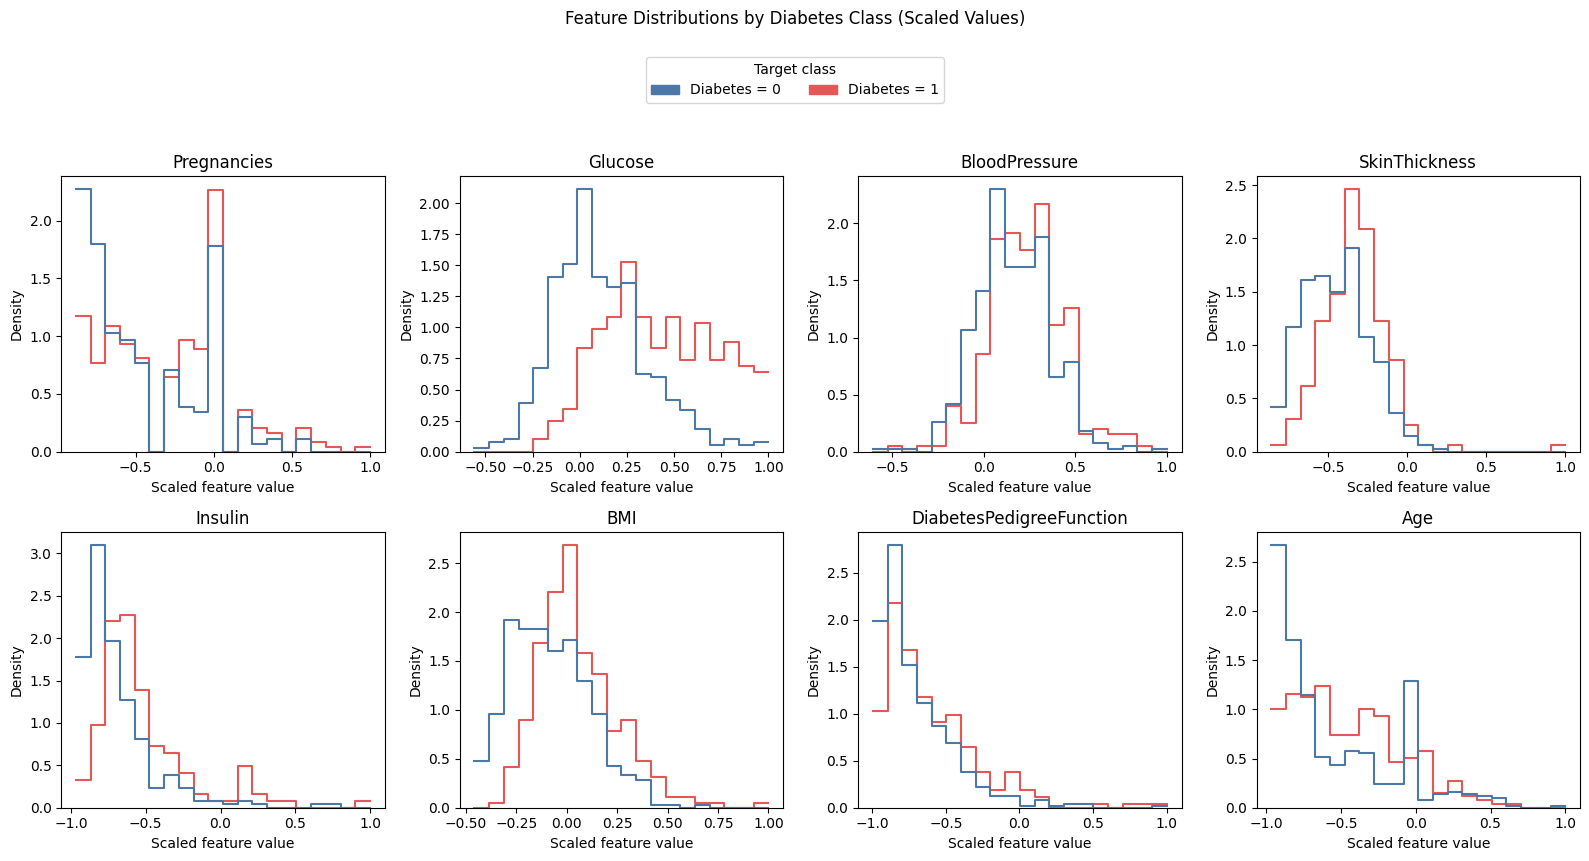

In [ ]:
distribution_df = df[FEATURE_NAMES + ["Diabetes"]].copy()
distribution_df[MISSING_ZERO_COLUMNS] = distribution_df[MISSING_ZERO_COLUMNS].replace(0, np.nan)
class_palette = {0: "#4C78A8", 1: "#E45756"}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for index, (axis, feature) in enumerate(zip(axes.flat, FEATURE_NAMES)):
    sns.histplot(
        data=distribution_df,
        x=feature,
        hue="Diabetes",
        bins=20,
        stat="density",
        common_norm=False,
        element="step",
        fill=False,
        palette=class_palette,
        legend=False,
        ax=axis,
    )
    axis.set_title(feature)
    axis.set_xlabel("Scaled feature value")
    axis.set_ylabel("Density")

from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=class_palette[0], edgecolor=class_palette[0], label="Diabetes = 0"),
    Patch(facecolor=class_palette[1], edgecolor=class_palette[1], label="Diabetes = 1"),
]
fig.legend(handles=legend_handles, title="Target class", loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Feature Distributions by Diabetes Class (Scaled Values)", y=1.07)
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(FIGURES_DIR / "feature_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

The class distributions overlap across all eight features, although the Diabetes=1 group appears shifted toward larger scaled values for Glucose, BMI, Insulin, and Pregnancies. These visual differences are descriptive rather than tests of statistical significance. Insulin and SkinThickness have many missing zero sentinels, so their plotted distributions use fewer observations and should be interpreted with particular caution.

In [ ]:
class_counts = df["Diabetes"].value_counts().sort_index()
print("Class distribution check:")
print(f"Diabetes=0: {class_counts[0]}")
print(f"Diabetes=1: {class_counts[1]}")
print("The moderate class imbalance is why stratification was used in the fixed split.")

Class distribution check:
Diabetes=0: 496
Diabetes=1: 263
The moderate class imbalance is why stratification was used in the fixed split.


## 5. PyTorch Neural Network Experiments

This section implements the required PyTorch baseline and HP_ID-modified experiments using the fixed preprocessed split from Step 3. The experiments are configured for CPU execution in Colab and use the same split and preprocessing for every run.

### 5.1 Experimental Configuration

| Setting | Baseline | Modified |
| --- | --- | --- |
| Hidden layers | `[64, 32]` | `[32]` |
| Learning rate | `0.001` | `0.001` |
| Epochs | `30` | `30` |
| Batch size | `32` | `32` |
| Optimizer | Adam | Adam |
| Loss | BCEWithLogitsLoss | BCEWithLogitsLoss |

Training uses seeds `9486`, `9487`, and `9488`, the fixed stratified 70/15/15 split, and the final Step 3 preprocessed arrays. Test accuracy is the evaluation metric, with class 1 predicted when its sigmoid probability is at least 0.5. The notebook selects the CPU device for these small experiments.

In [21]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

BATCH_SIZE = 32
DEVICE = torch.device("cpu")
print("Selected device:", DEVICE)


def set_pytorch_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except (AttributeError, TypeError):
        pass


class PyTorchBinaryClassifier(nn.Module):
    def __init__(self, input_size, hidden_layers):
        super().__init__()
        layers = []
        current_size = input_size
        for hidden_size in hidden_layers:
            layers.extend([nn.Linear(current_size, hidden_size), nn.ReLU()])
            current_size = hidden_size
        layers.append(nn.Linear(current_size, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, features):
        return self.network(features)


def count_trainable_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

set_pytorch_seed(SEED)
baseline_model = PyTorchBinaryClassifier(len(FEATURE_NAMES), BASELINE_CONFIG["hidden_layers"])
modified_model = PyTorchBinaryClassifier(len(FEATURE_NAMES), MODIFIED_CONFIG["hidden_layers"])
print("Baseline architecture:", baseline_model)
print("Baseline trainable parameters:", count_trainable_parameters(baseline_model))
print("Modified architecture:", modified_model)
print("Modified trainable parameters:", count_trainable_parameters(modified_model))

Selected device: cpu
Baseline architecture: PyTorchBinaryClassifier(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)
Baseline trainable parameters: 2689
Modified architecture: PyTorchBinaryClassifier(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)
Modified trainable parameters: 321


### 5.2 Model Definition

In [22]:
# Convert the existing final processed arrays without re-splitting or re-preprocessing.
X_train_tensor = torch.from_numpy(X_train).to(torch.float32)
X_val_tensor = torch.from_numpy(X_val).to(torch.float32)
X_test_tensor = torch.from_numpy(X_test).to(torch.float32)
y_train_tensor = torch.from_numpy(y_train).to(torch.float32).reshape(-1, 1)
y_val_tensor = torch.from_numpy(y_val).to(torch.float32).reshape(-1, 1)
y_test_tensor = torch.from_numpy(y_test).to(torch.float32).reshape(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
validation_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)


def create_pytorch_dataloaders(training_seed):
    generator = torch.Generator()
    generator.manual_seed(training_seed)
    return (
        DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=generator, num_workers=0),
        DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0),
        DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0),
    )

print("Tensor shapes:", {
    "X_train": tuple(X_train_tensor.shape),
    "y_train": tuple(y_train_tensor.shape),
    "X_val": tuple(X_val_tensor.shape),
    "y_val": tuple(y_val_tensor.shape),
    "X_test": tuple(X_test_tensor.shape),
    "y_test": tuple(y_test_tensor.shape),
})

Tensor shapes: {'X_train': (531, 8), 'y_train': (531, 1), 'X_val': (114, 8), 'y_val': (114, 1), 'X_test': (114, 8), 'y_test': (114, 1)}


### 5.3 Reusable Training and Evaluation Function

In [23]:
def train_pytorch_model(config, training_seed):
    set_pytorch_seed(training_seed)
    model = PyTorchBinaryClassifier(len(FEATURE_NAMES), config["hidden_layers"]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])
    criterion = nn.BCEWithLogitsLoss()
    train_loader, validation_loader, test_loader = create_pytorch_dataloaders(training_seed)
    history = {"epoch": [], "train_loss": [], "validation_loss": []}

    for epoch in range(1, config["epochs"] + 1):
        model.train()
        train_loss_total = 0.0
        train_sample_count = 0
        for features, targets in train_loader:
            features, targets = features.to(DEVICE), targets.to(DEVICE)
            optimizer.zero_grad()
            logits = model(features)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()
            batch_size = features.size(0)
            train_loss_total += loss.item() * batch_size
            train_sample_count += batch_size

        model.eval()
        validation_loss_total = 0.0
        validation_sample_count = 0
        with torch.no_grad():
            for features, targets in validation_loader:
                features, targets = features.to(DEVICE), targets.to(DEVICE)
                logits = model(features)
                loss = criterion(logits, targets)
                batch_size = features.size(0)
                validation_loss_total += loss.item() * batch_size
                validation_sample_count += batch_size

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss_total / train_sample_count)
        history["validation_loss"].append(validation_loss_total / validation_sample_count)

    model.eval()
    test_probabilities = []
    test_targets = []
    with torch.no_grad():
        for features, targets in test_loader:
            logits = model(features.to(DEVICE))
            test_probabilities.append(torch.sigmoid(logits).cpu())
            test_targets.append(targets)
    test_probabilities = torch.cat(test_probabilities).reshape(-1)
    test_targets = torch.cat(test_targets).reshape(-1)
    test_predictions = (test_probabilities >= 0.5).to(torch.float32)
    test_accuracy = (test_predictions == test_targets).to(torch.float32).mean().item()

    return model, history, test_accuracy, test_probabilities.numpy(), test_predictions.numpy()

print("Reusable training function defined; no training runs are executed in this setup cell.")

Reusable training function defined; no training runs are executed in this setup cell.


### 5.4 Baseline and Modified Training Runs

In [24]:
PYTORCH_CONFIGS = {
    "Baseline": BASELINE_CONFIG,
    "Modified": MODIFIED_CONFIG,
}

pytorch_run_records = []
pytorch_histories = {}
checkpoint_directory = Path("checkpoints/pytorch")
checkpoint_directory.mkdir(parents=True, exist_ok=True)

for model_name, config in PYTORCH_CONFIGS.items():
    for training_seed in TRAINING_SEEDS:
        model, history, test_accuracy, test_probabilities, test_predictions = train_pytorch_model(config, training_seed)
        run_key = (model_name, training_seed)
        pytorch_histories[run_key] = history
        checkpoint_path = checkpoint_directory / f"pytorch_{model_name.lower()}_seed_{training_seed}.pt"
        torch.save({
            "model_state_dict": model.state_dict(),
            "model_name": model_name,
            "hidden_layers": config["hidden_layers"],
            "learning_rate": config["learning_rate"],
            "epochs": config["epochs"],
            "training_seed": training_seed,
            "input_size": len(FEATURE_NAMES),
            "feature_names": FEATURE_NAMES,
            "test_accuracy": test_accuracy,
            "final_train_loss": history["train_loss"][-1],
            "final_validation_loss": history["validation_loss"][-1],
        }, checkpoint_path)
        pytorch_run_records.append({
            "Framework": "PyTorch",
            "Model": model_name,
            "Seed": training_seed,
            "Hidden Layers": str(config["hidden_layers"]),
            "Learning Rate": config["learning_rate"],
            "Epochs": config["epochs"],
            "Final Train Loss": history["train_loss"][-1],
            "Final Validation Loss": history["validation_loss"][-1],
            "Test Accuracy": test_accuracy,
        })
        print({
            "Framework": "PyTorch",
            "Model": model_name,
            "Seed": training_seed,
            "Hidden Layers": config["hidden_layers"],
            "Learning Rate": config["learning_rate"],
            "Epochs": config["epochs"],
            "Final Train Loss": history["train_loss"][-1],
            "Final Validation Loss": history["validation_loss"][-1],
            "Test Accuracy": test_accuracy,
        })

pytorch_results_df = pd.DataFrame(pytorch_run_records, columns=[
    "Framework", "Model", "Seed", "Hidden Layers", "Learning Rate", "Epochs",
    "Final Train Loss", "Final Validation Loss", "Test Accuracy",
])
display(pytorch_results_df)
print("The six PyTorch runs execute when this cell is run in the final Colab environment.")

{'Framework': 'PyTorch', 'Model': 'Baseline', 'Seed': 9486, 'Hidden Layers': [64, 32], 'Learning Rate': 0.001, 'Epochs': 30, 'Final Train Loss': 0.4061901019342426, 'Final Validation Loss': 0.5196852684020996, 'Test Accuracy': 0.7982456088066101}
{'Framework': 'PyTorch', 'Model': 'Baseline', 'Seed': 9487, 'Hidden Layers': [64, 32], 'Learning Rate': 0.001, 'Epochs': 30, 'Final Train Loss': 0.39371493037811106, 'Final Validation Loss': 0.5209291242716605, 'Test Accuracy': 0.7894737124443054}
{'Framework': 'PyTorch', 'Model': 'Baseline', 'Seed': 9488, 'Hidden Layers': [64, 32], 'Learning Rate': 0.001, 'Epochs': 30, 'Final Train Loss': 0.4080526209708212, 'Final Validation Loss': 0.5359846531299123, 'Test Accuracy': 0.7894737124443054}
{'Framework': 'PyTorch', 'Model': 'Modified', 'Seed': 9486, 'Hidden Layers': [32], 'Learning Rate': 0.001, 'Epochs': 30, 'Final Train Loss': 0.4490796123296303, 'Final Validation Loss': 0.5211900054362782, 'Test Accuracy': 0.8157894611358643}
{'Framework': '

,Framework,Model,Seed,Hidden Layers,Learning Rate,Epochs,Final Train Loss,Final Validation Loss,Test Accuracy
0,PyTorch,Baseline,9486,"[64, 32]",0.001,30,0.406190,0.519685,0.798246
1,PyTorch,Baseline,9487,"[64, 32]",0.001,30,0.393715,0.520929,0.789474
2,PyTorch,Baseline,9488,"[64, 32]",0.001,30,0.408053,0.535985,0.789474
3,PyTorch,Modified,9486,[32],0.001,30,0.449080,0.521190,0.815789
4,PyTorch,Modified,9487,[32],0.001,30,0.442711,0.509449,0.798246
5,PyTorch,Modified,9488,[32],0.001,30,0.445218,0.519650,0.798246


The six PyTorch runs execute when this cell is run in the final Colab environment.


### 5.5 Test Accuracy Summary

In [25]:
pytorch_summary_records = []
for model_name, model_results in pytorch_results_df.groupby("Model", sort=False):
    accuracies = model_results["Test Accuracy"].to_numpy()
    pytorch_summary_records.append({
        "Model": model_name,
        "Number of Runs": len(accuracies),
        "Mean Test Accuracy": np.mean(accuracies),
        "Sample Std. Dev.": np.std(accuracies, ddof=1),
        "Minimum Test Accuracy": np.min(accuracies),
        "Maximum Test Accuracy": np.max(accuracies),
    })
pytorch_summary_df = pd.DataFrame(pytorch_summary_records)
pytorch_summary_df["Mean Accuracy (%)"] = pytorch_summary_df["Mean Test Accuracy"] * 100
display(pytorch_summary_df)
print("Sample standard deviation uses np.std(accuracies, ddof=1).")

,Model,Number of Runs,Mean Test Accuracy,Sample Std. Dev.,Minimum Test Accuracy,Maximum Test Accuracy,Mean Accuracy (%)
0,Baseline,3,0.792398,0.005064,0.789474,0.798246,79.239768
1,Modified,3,0.804094,0.010129,0.798246,0.815789,80.409356


Sample standard deviation uses np.std(accuracies, ddof=1).


### 5.6 Training and Validation Loss Curves

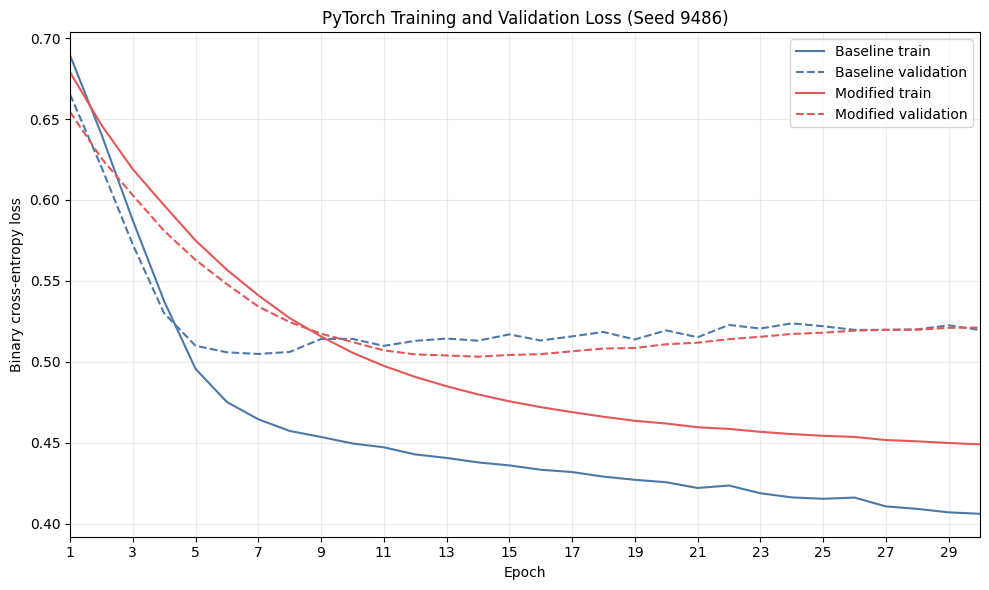

{'Model': 'Baseline', 'Minimum validation-loss epoch': 7, 'Minimum validation loss': 0.504894587031582, 'Final validation loss': 0.5196852684020996, 'Final training loss': 0.4061901019342426, 'Final validation minus training': 0.11349516646785701}
{'Model': 'Modified', 'Minimum validation-loss epoch': 14, 'Minimum validation loss': 0.5032110569769876, 'Final validation loss': 0.5211900054362782, 'Final training loss': 0.4490796123296303, 'Final validation minus training': 0.07211039310664796}


In [26]:
seed_for_curve = 9486
baseline_history = pytorch_histories[("Baseline", seed_for_curve)]
modified_history = pytorch_histories[("Modified", seed_for_curve)]

plt.figure(figsize=(10, 6))
plt.plot(baseline_history["epoch"], baseline_history["train_loss"], label="Baseline train", color="#4C78A8")
plt.plot(baseline_history["epoch"], baseline_history["validation_loss"], label="Baseline validation", color="#4C78A8", linestyle="--")
plt.plot(modified_history["epoch"], modified_history["train_loss"], label="Modified train", color="#E45756")
plt.plot(modified_history["epoch"], modified_history["validation_loss"], label="Modified validation", color="#E45756", linestyle="--")
plt.title("PyTorch Training and Validation Loss (Seed 9486)")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.xlim(1, 30)
plt.xticks(range(1, 31, 2))
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(Path("figures") / "pytorch_loss_curves.png", dpi=300, bbox_inches="tight")
plt.show()

for model_name, history in [("Baseline", baseline_history), ("Modified", modified_history)]:
    minimum_index = int(np.argmin(history["validation_loss"]))
    final_validation_loss = history["validation_loss"][-1]
    final_train_loss = history["train_loss"][-1]
    print({
        "Model": model_name,
        "Minimum validation-loss epoch": history["epoch"][minimum_index],
        "Minimum validation loss": history["validation_loss"][minimum_index],
        "Final validation loss": final_validation_loss,
        "Final training loss": final_train_loss,
        "Final validation minus training": final_validation_loss - final_train_loss,
    })

### 5.7 Preliminary PyTorch Interpretation

Placeholder: complete the PyTorch curve diagnosis and comparison after the six runs are executed in Google Colab. No conclusion about overfitting, underfitting, or relative model performance is recorded before those results are available.